# ITEC5920 - Assignment 3 - Question 1
Earle Estrella

100907269

## Question 1.1

In [31]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, Flatten, SimpleRNN, LSTM, GRU
from keras.backend import clear_session

# From Assignment Specs
def generate_time_series(batch_size, n_steps):
    freq1, freq2, offsets1, offsets2 = np.random.rand(4, batch_size, 1)
    time = np.linspace(0, 1, n_steps)
    series = 0.6 * np.sin((time - offsets1) * (freq1 * 10 + 10))
    return series[..., np.newaxis].astype(np.float32)

np.random.seed(42)

n_steps = 60
series  = generate_time_series(11000, n_steps + 1)
X_train, y_train = series[:8000,      :n_steps], series[:8000,      -1]
X_valid, y_valid = series[8000:10000, :n_steps], series[8000:10000, -1]
X_test,  y_test  = series[10000:,     :n_steps], series[10000:,     -1]

# Reshaping
print("X_train:", X_train.shape, "  y_train:", y_train.shape)
print("X_valid:", X_valid.shape, "  y_valid:", y_valid.shape)
print("X_test: ", X_test.shape,  "  y_test: ", y_test.shape)

X_train: (8000, 60, 1)   y_train: (8000, 1)
X_valid: (2000, 60, 1)   y_valid: (2000, 1)
X_test:  (1000, 60, 1)   y_test:  (1000, 1)


In [32]:
# Model Creator Functions
# Create linear prediction model
def create_linear(dense_units, input_shape):
    clear_session()
    model = Sequential([
        Flatten(input_shape=input_shape),
        Dense(dense_units)
    ], name="Linear")
    model.compile(loss='mean_squared_error', optimizer='adam')
    return model

# Create simple RNN model
def create_simple_RNN(hidden_units, dense_units, input_shape, activation):
    clear_session()
    model = Sequential([
        SimpleRNN(hidden_units, input_shape=input_shape, activation=activation[0]),
        Dense(units=dense_units, activation=activation[1])
    ], name="SimpleRNN")
    model.compile(loss='mean_squared_error', optimizer='adam')
    return model

# Create deep RNN model
def create_deep_RNN(hidden_units, dense_units, input_shape, activation):
    clear_session()
    model = Sequential([
        SimpleRNN(hidden_units, return_sequences=True, input_shape=input_shape, activation=activation[0]),
        SimpleRNN(hidden_units, activation=activation[0]),
        Dense(units=dense_units, activation=activation[1])
    ], name="DeepRNN")
    model.compile(loss='mean_squared_error', optimizer='adam')
    return model

# Create LSTM model
def create_LSTM(hidden_units, dense_units, input_shape, activation):
    clear_session()
    model = Sequential([
        LSTM(hidden_units, input_shape=input_shape, activation=activation[0]),
        Dense(units=dense_units, activation=activation[1])
    ], name="LSTM")
    model.compile(loss='mean_squared_error', optimizer='adam')
    return model

# Create GRU model
def create_GRU(hidden_units, dense_units, input_shape, activation):
    clear_session()
    model = Sequential([
        GRU(hidden_units, input_shape=input_shape, activation=activation[0]),
        Dense(units=dense_units, activation=activation[1])
    ], name="GRU")
    model.compile(loss='mean_squared_error', optimizer='adam')
    return model

Created creator functions for model. The creator functions are made similarly from the tutorial. This was extended for linear prediction as the baseline and created deep RNN for a stacked architecture. Each function calls clear_session() before building to reset session and compipled with MSE as loss and adam as optimizer.
The activation parameter accepts activation[0] for the recurrent layer and activation[1] for the Dense output layer. Linear prediction does not use this since its a baseline with no activation function by definition. Deep RNN adds return_sequences=True

In [33]:
# Helper code to calculate error
def print_error(model, X_train, Y_train, X_valid, Y_valid, X_test, Y_test):
    train_mse = model.evaluate(X_train, Y_train, verbose=0)
    valid_mse = model.evaluate(X_valid, Y_valid, verbose=0)
    test_mse  = model.evaluate(X_test,  Y_test,  verbose=0)
    print('Train MSE: %.6f' % train_mse)
    print('Valid MSE: %.6f' % valid_mse)
    print('Test  MSE: %.6f' % test_mse)
    return train_mse, valid_mse, test_mse

results = {}

Created helper for MSE calculation since it will be used often. Calculates it for Training, Validation and Test.

Hyperparameters are defined so they can be used across the different models used. Each model is made to fit for 20 epochs with batch size of 64 and validated with the data that was split for validation to report loss at each epoch. Using batch size of 64 over 1 makes it such that training is faster when compared to the tutorial code.

In [34]:
input_shape  = (n_steps, 1)
hidden_units = 20
dense_units  = 1

# Create histories to keep track for plot purposes
histories_1 = {}
# Create models and list them as tupples
models_to_train = [
    ("Linear",    create_linear(dense_units, input_shape)),
    ("SimpleRNN", create_simple_RNN(hidden_units, dense_units, input_shape, activation=['tanh', 'tanh'])),
    ("DeepRNN",   create_deep_RNN(hidden_units, dense_units, input_shape, activation=['tanh', 'tanh'])),
    ("LSTM",      create_LSTM(hidden_units, dense_units, input_shape, activation=['tanh', 'tanh'])),
    ("GRU",       create_GRU(hidden_units, dense_units, input_shape, activation=['tanh', 'tanh'])),
]

# Loop over the models
for name, model in models_to_train:
    model.summary()
    histories_1[name] = model.fit(
        X_train, y_train,
        epochs          = 20,
        batch_size      = 64,
        validation_data = (X_valid, y_valid),
        verbose         = 1
    )
    print(f"\n{name} — MSE:")
    results[name] = print_error(
        model, X_train, y_train, X_valid, y_valid, X_test, y_test)

Model: "Linear"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            61 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61 (244.00 B)

 Trainable params: 61 (244.00 B)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 20)             │         1,380 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,401 (5.47 KB)

 Trainable params: 1,401 (5.47 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0339 - val_loss: 0.0036
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0025 - val_loss: 0.0016
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0012 - val_loss: 8.1845e-04
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.7786e-04 - val_loss: 5.3326e-04
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 4.9512e-04 - val_loss: 4.2289e-04
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 4.0039e-04 - val_loss: 3.8354e-04
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3.4604e-04 - val_loss: 3.1151e-04
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3.0817e-04 - val_loss: 2.9233e-04
Epoch 9/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.8410e-04 - val_loss: 2.7521e-04
Epoch 10/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.7233e-04 - val_loss: 2.6747e-04
Epoch 11/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.5604e-04 - val_l

In [35]:
print(f"\n{'Model':<12}  {'Train MSE':>12}  {'Valid MSE':>12}  {'Test MSE':>12}")
for name, (tr, va, te) in results.items():
    print(f"{name:<12}  {tr:>12.6f}  {va:>12.6f}  {te:>12.6f}")


Model            Train MSE     Valid MSE      Test MSE
Linear            0.000076      0.000075      0.000082
SimpleRNN         0.000399      0.000398      0.000404
DeepRNN           0.000009      0.000009      0.000008
LSTM              0.000017      0.000017      0.000018
GRU               0.000070      0.000071      0.000070


The linear model performs the worst as it is the baseline model. Any model that cannot outperform it does not meaningfully capture sequential structure. All models significantly improve over the linear baseline which confirms that temporal ordering carries predictive information. Deep RNN achieves the lowest MSE outperforming LSTM and GRU. This suggests that for a regular sine wave pattern, additional depth through stacked recurrent layers contributes more than gating mechanisms. Training, Validation and Test MSE are consistently close across all models which indicates no overfitting.

## Question 1.2

This time, there are an additional 10 steps instead of just 1. This is the only change from the previous section.

In [36]:
series = generate_time_series(11000, n_steps + 10)

X_train, Y_train = series[:8000,      :n_steps], series[:8000,      -10:, 0]
X_valid, Y_valid = series[8000:10000, :n_steps], series[8000:10000, -10:, 0]
X_test,  Y_test  = series[10000:,     :n_steps], series[10000:,     -10:, 0]

print("X_train:", X_train.shape, "  Y_train:", Y_train.shape)
print("X_valid:", X_valid.shape, "  Y_valid:", Y_valid.shape)
print("X_test: ", X_test.shape,  "  Y_test: ", Y_test.shape)

X_train: (8000, 60, 1)   Y_train: (8000, 10)
X_valid: (2000, 60, 1)   Y_valid: (2000, 10)
X_test:  (1000, 60, 1)   Y_test:  (1000, 10)


Same creator functions are used as the last so jump straight to the training. The main change is that dense_units is now 10 instead of 1. Variables are changed to capital Y as well for plotting purposes.

In [37]:
input_shape  = (n_steps, 1)
hidden_units = 20
dense_units  = 10

# Create histories to keep track for plot purposes
histories_2 = {}
# Create models and put them in an array
models_to_train = [
    ("Linear",    create_linear(dense_units, input_shape)),
    ("SimpleRNN", create_simple_RNN(hidden_units, dense_units, input_shape, activation=['tanh', 'tanh'])),
    ("DeepRNN",   create_deep_RNN(hidden_units, dense_units, input_shape, activation=['tanh', 'tanh'])),
    ("LSTM",      create_LSTM(hidden_units, dense_units, input_shape, activation=['tanh', 'tanh'])),
    ("GRU",       create_GRU(hidden_units, dense_units, input_shape, activation=['tanh', 'tanh'])),
]

# Loop over the models
for name, model in models_to_train:
    model.summary()
    histories_2[name] = model.fit(
        X_train, Y_train,
        epochs          = 20,
        batch_size      = 64,
        validation_data = (X_valid, Y_valid),
        verbose         = 1
    )
    print(f"\n{name} — MSE:")
    results[name] = print_error(
        model, X_train, Y_train, X_valid, Y_valid, X_test, Y_test)

Model: "Linear"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │           610 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 610 (2.38 KB)

 Trainable params: 610 (2.38 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 20)             │         1,380 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │           210 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,590 (6.21 KB)

 Trainable params: 1,590 (6.21 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1112 - val_loss: 0.0290
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0220 - val_loss: 0.0197
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0181 - val_loss: 0.0171
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0155 - val_loss: 0.0150
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0128 - val_loss: 0.0116
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0103 - val_loss: 0.0091
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0085 - val_loss: 0.0075
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0072 - val_loss: 0.0061
Epoch 9/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0052 - val_loss: 0.0039
Epoch 10/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0030 - val_loss: 0.0021
Epoch 11/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0018 - val_loss: 0.0021
Epoch 12/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

In [38]:
print(f"\n{'Model':<12}  {'Train MSE':>12}  {'Valid MSE':>12}  {'Test MSE':>12}")
for name, (tr, va, te) in results.items():
    print(f"{name:<12}  {tr:>12.6f}  {va:>12.6f}  {te:>12.6f}")


Model            Train MSE     Valid MSE      Test MSE
Linear            0.002803      0.002990      0.002804
SimpleRNN         0.000887      0.000919      0.000867
DeepRNN           0.000200      0.000207      0.000192
LSTM              0.000171      0.000172      0.000170
GRU               0.000697      0.000720      0.000702


All models showed increased MSE compared to the previous section which is expected because predicting 10 steps ahead requires the model to produce a coherent sequence of future values instead of a single next value which means more errors. The linear model degrades the most while Deep RNN still performs the best with the lowest increase. 

## Question 1.3

In [39]:
def plot_loss(histories, title):
    fig, axes = plt.subplots(1, len(histories), figsize=(20, 4))
    for ax, (name, history) in zip(axes, histories.items()):
        ax.plot(history.history['loss'],     label='Train loss')
        ax.plot(history.history['val_loss'], label='Valid loss')
        ax.set_title(name)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.legend()
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

def plot_loss_combined(histories, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for name, history in histories.items():
        axes[0].plot(history.history['loss'],     label=name)
        axes[1].plot(history.history['val_loss'], label=name)

    axes[0].set_title('Train Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    axes[1].set_title('Validation Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

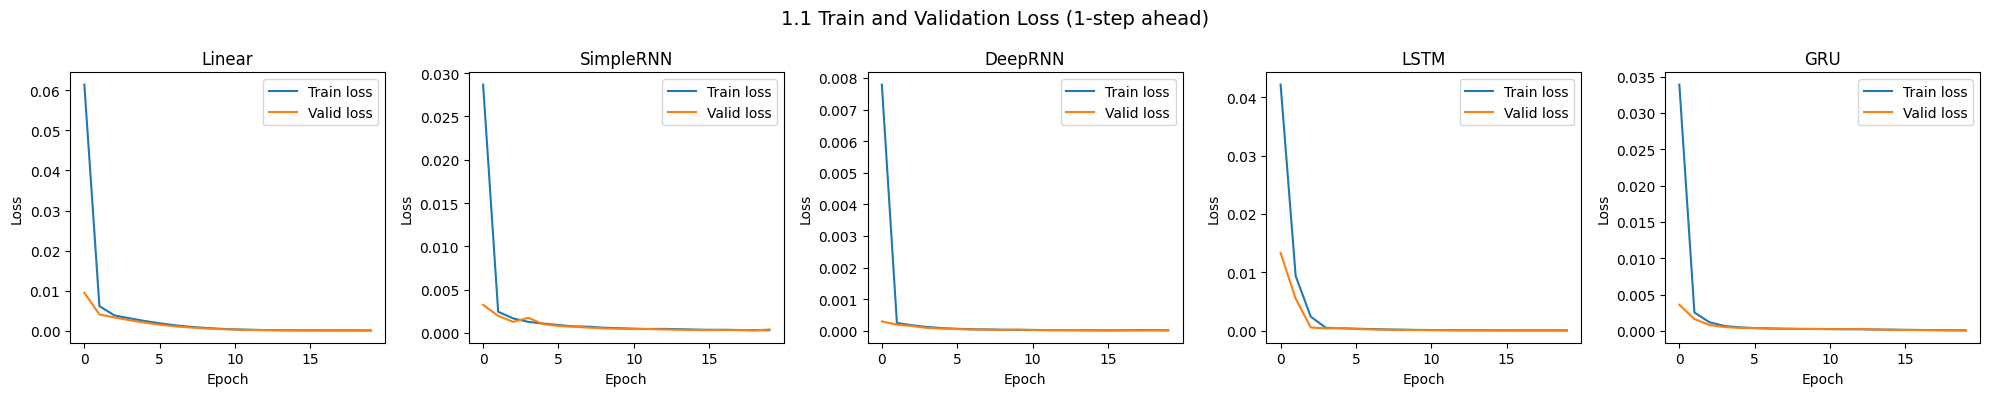

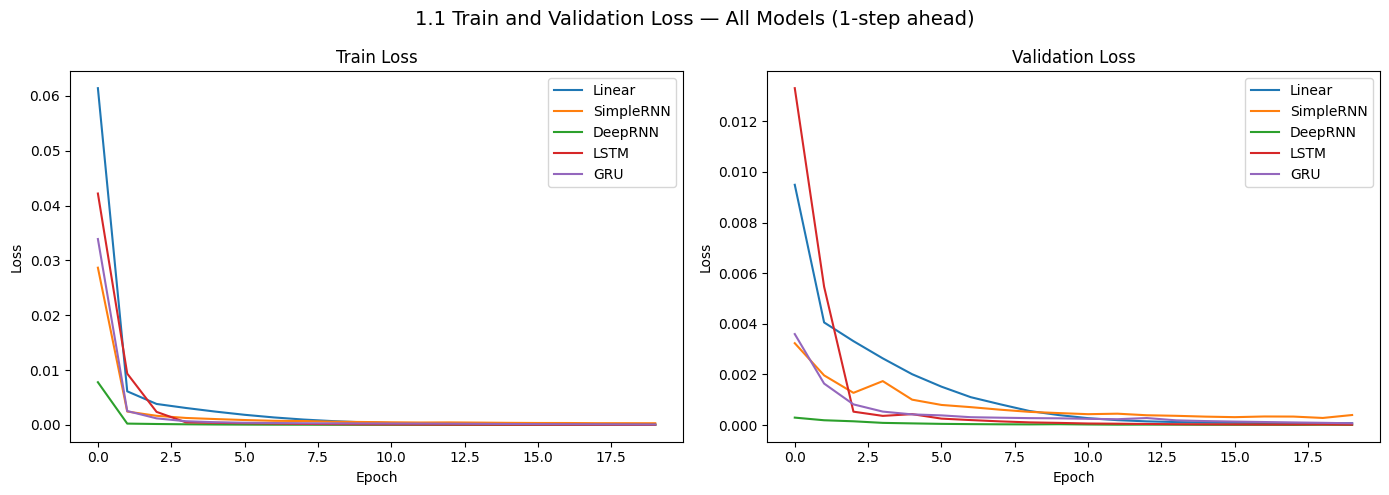

In [40]:
plot_loss(histories_1, title='1.1 Train and Validation Loss (1-step ahead)')
plot_loss_combined(histories_1, title='1.1 Train and Validation Loss — All Models (1-step ahead)')

Graphs for 1.1:
All models converge rapidly within the first few epochs and flatten out for the rest of the epochs which means fast learning on single-step task. The separate graphs for each model show the difference between training and validation loss. The y-axis scales differ between models showing the gap in performance by each model and can be clearly seen in the combined graphs for both training and validation loss to show the difference between the models.

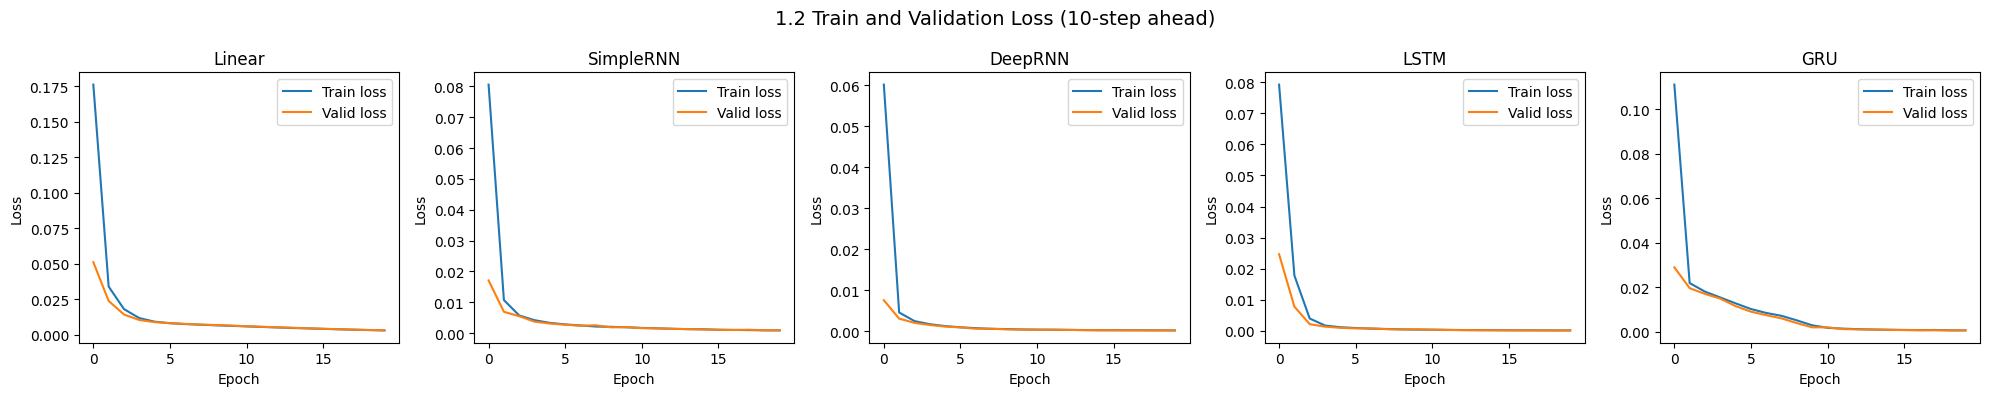

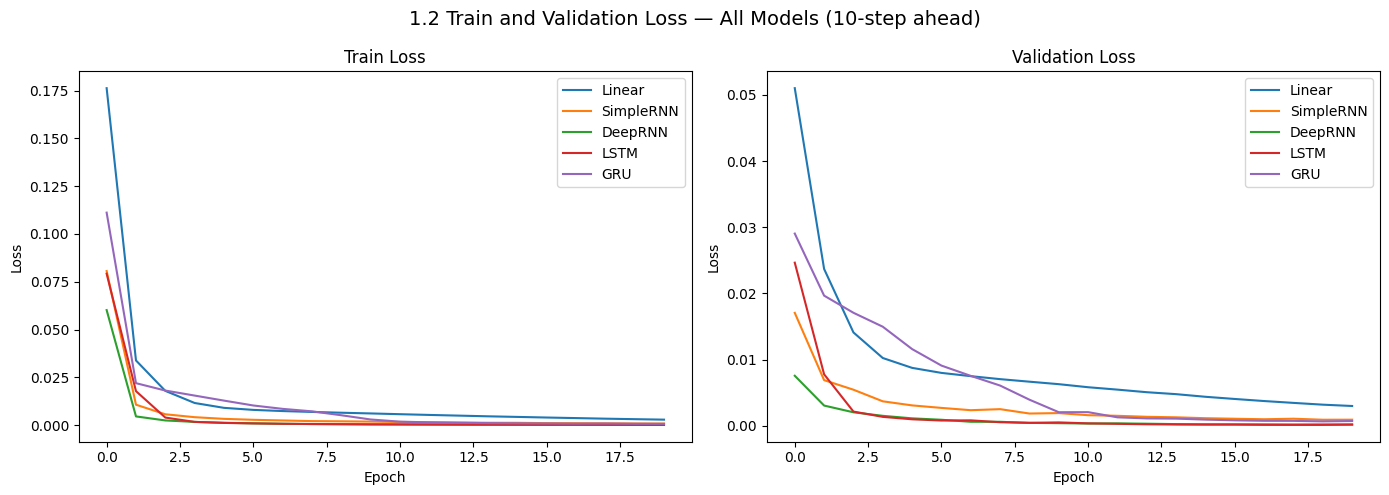

In [41]:
plot_loss(histories_2, title='1.2 Train and Validation Loss (10-step ahead)')
plot_loss_combined(histories_2, title='1.2 Train and Validation Loss — All Models (10-step ahead)')

Graphs for 1.2:
The same observations can be made for all models where they converge rapidly within the first few epochs and flatten out for the rest of the epochs but the highest possible values were roughly halved compared to 1.1 results. The y-axis scales are closer together compared to 1.1 but it still shows that Deep RNN started performing better sooner compared to the other models.